#Mounting Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
cd /content/drive/MyDrive/Deep-Emotion

/content/drive/MyDrive/Deep-Emotion


#Installing Libraries

In [3]:
!pip3 install --upgrade --no-cache-dir gdown

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Attempting uninstall: gdown
    Found existing installation: gdown 4.4.0
    Uninstalling gdown-4.4.0:
      Successfully uninstalled gdown-4.4.0


#Importing Libraries

In [4]:
from __future__ import print_function
import argparse
import numpy  as np
import os
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.utils.data.sampler import SubsetRandomSampler
from torchvision import transforms
import matplotlib.pyplot as plt
from data_loaders import Plain_Dataset, eval_data_dataloader

from generate_data import Generate_data
import cv2
import pandas as pd
import numpy as np


#Defining Variables

In [5]:
setup=True  #ONLY SET TRUE ONCE THEN SET TO FALSE
data='data'
                            
hyperparams=False
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")                    
epochs=100
learning_rate=0.005
batch_size=128
train=True



model='deep_emotion-80-128-0.005.pt'
test_acc=True
cam=False


#Downloading Dataset

In [6]:
if os.path.exists(data) is False:
  print("Downloading Dataset")
  !mkdir data
  !gdown https://drive.google.com/u/0/uc?id=1aUj1cyXCsDuLpybzwmsbuVjMJujRVnPZ&export=download
  !gdown https://drive.google.com/u/0/uc?id=15YRRU3wbSkOJxmk7hfizwuf729feGi2i&export=download
  !unzip train.csv.zip -d data
  !unzip test.csv.zip -d data
else:
  print('Dataset already Downloaded')

Downloading...
From: https://drive.google.com/u/0/uc?id=1aUj1cyXCsDuLpybzwmsbuVjMJujRVnPZ
To: /content/drive/MyDrive/Deep-Emotion/train.csv.zip
100% 81.1M/81.1M [00:03<00:00, 23.3MB/s]
Downloading...
From: https://drive.google.com/u/0/uc?id=15YRRU3wbSkOJxmk7hfizwuf729feGi2i
To: /content/drive/MyDrive/Deep-Emotion/test.csv.zip
100% 20.3M/20.3M [00:00<00:00, 22.2MB/s]
Archive:  train.csv.zip
  inflating: data/train.csv          
Archive:  test.csv.zip
  inflating: data/test.csv           


#Defining Model


In [7]:
class Deep_Emotion(nn.Module):
    def __init__(self):
        '''
        Deep_Emotion class contains the network architecture.
        '''
        super(Deep_Emotion,self).__init__()
        self.conv1 = nn.Conv2d(1,10,3)
        self.conv2 = nn.Conv2d(10,10,3)
        self.pool2 = nn.MaxPool2d(2,2)

        self.conv3 = nn.Conv2d(10,10,3)
        self.conv4 = nn.Conv2d(10,10,3)
        self.pool4 = nn.MaxPool2d(2,2)

        self.norm = nn.BatchNorm2d(10)

        self.fc1 = nn.Linear(810,50)
        self.fc2 = nn.Linear(50,7)

        self.localization = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=7),
            nn.MaxPool2d(2, stride=2),
            nn.ReLU(True),
            nn.Conv2d(8, 10, kernel_size=5),
            nn.MaxPool2d(2, stride=2),
            nn.ReLU(True)
        )

        self.fc_loc = nn.Sequential(
            nn.Linear(640, 32),
            nn.ReLU(True),
            nn.Linear(32, 3 * 2)
        )
        self.fc_loc[2].weight.data.zero_()
        self.fc_loc[2].bias.data.copy_(torch.tensor([1, 0, 0, 0, 1, 0], dtype=torch.float))

    def stn(self, x):
        xs = self.localization(x)
        xs = xs.view(-1, 640)
        theta = self.fc_loc(xs)
        theta = theta.view(-1, 2, 3)

        grid = F.affine_grid(theta, x.size())
        x = F.grid_sample(x, grid)
        return x

    def forward(self,input):
        out = self.stn(input)

        out = F.relu(self.conv1(out))
        out = self.conv2(out)
        out = F.relu(self.pool2(out))

        out = F.relu(self.conv3(out))
        out = self.norm(self.conv4(out))
        out = F.relu(self.pool4(out))

        out = F.dropout(out)
        out = out.view(-1, 810)
        out = F.relu(self.fc1(out))
        out = self.fc2(out)

        return out


#Training Script

In [8]:
def Train(epochs,train_loader,val_loader,criterion,optmizer,device):
    '''
    Training Loop
    '''
    print("===================================Start Training===================================")
    for e in range(epochs):
        train_loss = 0
        validation_loss = 0
        train_correct = 0
        val_correct = 0
        # Train the model  #
        net.train()
        for data, labels in train_loader:
            data, labels = data.to(device), labels.to(device)
            optmizer.zero_grad()
            outputs = net(data)
            loss = criterion(outputs,labels)
            loss.backward()
            optmizer.step()
            train_loss += loss.item()
            _, preds = torch.max(outputs,1)
            train_correct += torch.sum(preds == labels.data)

        #validate the model#
        net.eval()
        for data,labels in val_loader:
            data, labels = data.to(device), labels.to(device)
            val_outputs = net(data)
            val_loss = criterion(val_outputs, labels)
            validation_loss += val_loss.item()
            _, val_preds = torch.max(val_outputs,1)
            val_correct += torch.sum(val_preds == labels.data)

        train_loss = train_loss/len(train_dataset)
        train_acc = train_correct.double() / len(train_dataset)
        validation_loss =  validation_loss / len(validation_dataset)
        val_acc = val_correct.double() / len(validation_dataset)
        print('Epoch: {} \tTraining Loss: {:.8f} \tValidation Loss {:.8f} \tTraining Acuuarcy {:.3f}% \tValidation Acuuarcy {:.3f}%'
                                                           .format(e+1, train_loss,validation_loss,train_acc * 100, val_acc*100))
        if e%20 ==0:
          torch.save(net.state_dict(),'deep_emotion-{}-{}-{}.pt'.format(e,batchsize,lr))
    print("===================================Training Finished===================================")





if setup :

    generate_dataset = Generate_data(data)
    generate_dataset.split_test()
    generate_dataset.save_images('train')
    generate_dataset.save_images('test')
    generate_dataset.save_images('val')

if hyperparams:
    epochs = epochs
    lr = learning_rate
    batchsize = batch_size
else :
    epochs = 100
    lr = 0.005
    batchsize = 128

if train:
    net = Deep_Emotion()
    
    net.to(device)
    print("Model archticture: ", net)
    traincsv_file = data+'/'+'train.csv'
    validationcsv_file = data+'/'+'val.csv'
    train_img_dir = data+'/'+'train/'
    validation_img_dir = data+'/'+'val/'

    transformation= transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5,),(0.5,))])
    train_dataset= Plain_Dataset(csv_file=traincsv_file, img_dir = train_img_dir, datatype = 'train', transform = transformation)
    validation_dataset= Plain_Dataset(csv_file=validationcsv_file, img_dir = validation_img_dir, datatype = 'val', transform = transformation)
    train_loader= DataLoader(train_dataset,batch_size=batchsize,shuffle = True,num_workers=0)
    val_loader=   DataLoader(validation_dataset,batch_size=batchsize,shuffle = True,num_workers=0)

    criterion= nn.CrossEntropyLoss()
    optmizer= optim.Adam(net.parameters(),lr= lr)
    Train(epochs, train_loader, val_loader, criterion, optmizer, device)


Done splitting the test file into validation & final test file


  8%|▊         | 1966/25120 [00:14<02:45, 140.14it/s]


KeyboardInterrupt: ignored

#Inference Script

Deep Emotion:- Deep_Emotion(
  (conv1): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
  (conv4): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (norm): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=810, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=7, bias=True)
  (localization): Sequential(
    (0): Conv2d(1, 8, kernel_size=(7, 7), stride=(1, 1))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ReLU(inplace=True)
    (3): Conv2d(8, 10, kernel_size=(5, 5), stride=(1, 1))
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (

/usr/local/lib/python3.8/dist-packages/torch/nn/functional.py:4289: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/torch/nn/functional.py:4227: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(


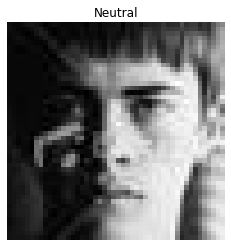

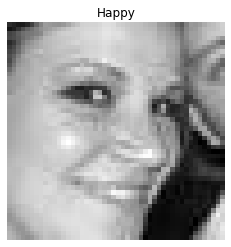

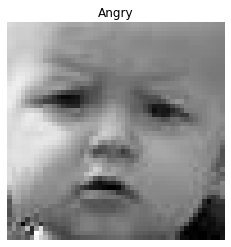

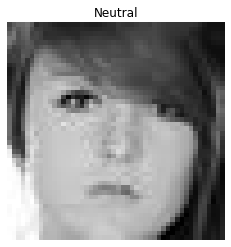

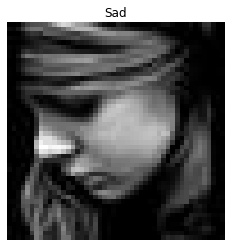

In [9]:
transformation = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5,),(0.5,))])
dataset = Plain_Dataset(csv_file=data+'/train.csv',img_dir = data+'/'+'train/',datatype = 'train',transform = transformation)
test_loader =  DataLoader(dataset,batch_size=64,num_workers=0)

net = Deep_Emotion()
print("Deep Emotion:-", net)
net.load_state_dict(torch.load(model))
net.to(device)
net.eval()
import matplotlib.pyplot as plt
classes = ('Angry', 'Disgust', 'Fear', 'Happy','Sad', 'Surprise', 'Neutral')
total = []
if test_acc:
    with torch.no_grad():
        for i, (data, labels) in enumerate(test_loader):
            
             # only display predictions for the first 5 images
                
            data, labels = data.to(device), labels.to(device)
            outputs = net(data)
            pred = F.softmax(outputs,dim=1)
            classs = torch.argmax(pred,1)
            for j in range(data.size()[0]):
                
                if j==5:
                  break
                img = data[j].cpu().numpy()
                plt.imshow(img[0],cmap='gray')
                plt.axis('off')
                plt.title(classes[classs[j].item()])
                plt.show()
            break
            # wrong = torch.where(classs != labels,torch.tensor([1.]).cuda(),torch.tensor([0.]).cuda())
            # acc = 1- (torch.sum(wrong) / 64)
            # total.append(acc.item())

    # print('Accuracy of the network on the test images: %d %%' % (100 * np.mean(total)))

